# Plant binary mask pipeline

NIR timelapse → **OpenCV** plant mask (Steps 1–8) → **PlantCV** morphology (stem / skeleton, later steps).

## Environment setup (once per machine)

After cloning on a **new computer**, run **one command** from the repo root (shut down any running notebook kernel first — Windows locks `cv2.pyd` if you `%pip` while Jupyter is active):

**Windows (PowerShell)** — use `.cmd` if you get an "execution policy" error:
```powershell
.\scripts\setup_plant_mask_notebook.cmd
```
Or: `powershell -ExecutionPolicy Bypass -File .\scripts\setup_plant_mask_notebook.ps1`

**macOS / Linux:**
```bash
bash scripts/setup_plant_mask_notebook.sh
```

That creates `.venv`, installs OpenCV + PlantCV, and registers the Jupyter kernel **`microneedle (plant mask)`**.

Then open this notebook, select that kernel, and run **the imports cell below**.

(Manual equivalent: `pip install -e ".[plant_timelapse]"`, then `requirements/plant_mask_notebook.txt` — see `scripts/setup_plant_mask_notebook.ps1`.)

## Mask pipeline (OpenCV)

1. Load TIFF  
2. Find edges (Sobel / …)  
3. Threshold edge mask  
4. Gaussian blur (σ ≈ 40 px)  
5. Otsu on soft mask  
6. Isolate plant blob (spatial CC) + AND with edges  
7. Denoise (salt & pepper)  
8. Fill small holes (not petiole gaps) → `mask_filled`

## Morphology (PlantCV)

Follow [PlantCV morphology tutorial](https://docs.plantcv.org/en/latest/morphology_tutorial/) on `mask_filled` (skeletonize → segment → stem metrics).

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

print("kernel:", sys.executable)
print("opencv:", cv2.__version__)

from plantcv import plantcv as pcv

pcv.params.debug = None  # set to "plot" in Jupyter for PlantCV morphology debug images
print("plantcv:", pcv.__version__)

kernel: c:\Users\smrkdt\Code\microneedle_IAA_Raman_analysis\.venv\Scripts\python.exe
opencv: 5.0.0
plantcv: 4.11.2


## Step 1 — Load TIFF

Edit `IMAGE_PATH` to your frame. `cv2.imread` with `IMREAD_ANYDEPTH | IMREAD_GRAYSCALE` preserves 16-bit grayscale TIFFs.

In [ ]:
IMAGE_PATH = Path(
    r"H:\My Drive\Work\DiSTAP\Research\Auxin IAA\IAA-MN longitudinal\IAA Nanosensor Experiment\In planta\Nb\Treatment_Control\Light_6to22\Temp_Hum_Variable\Run 4\DEV_1AB22C05B465\timelapse_2026-05-07_12-56-08\tl_2026-05-06_16-28-47.tif"
)

assert IMAGE_PATH.exists(), f"Image not found: {IMAGE_PATH}"

gray = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_ANYDEPTH | cv2.IMREAD_GRAYSCALE)
if gray is None:
    raise ValueError(f"OpenCV could not decode: {IMAGE_PATH}")

print("path:", IMAGE_PATH)
print("shape:", gray.shape)
print("dtype:", gray.dtype)
print("min / max:", int(gray.min()), int(gray.max()))

# 8-bit preview (min–max stretch for display only; keep `gray` at native depth)
gray_display = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(gray_display, cmap="gray")
ax.set_title(IMAGE_PATH.name)
ax.axis("off")
plt.show()

AssertionError: Image not found: G:\My Drive\Work\DiSTAP\Research\Auxin IAA\IAA-MN longitudinal\IAA Nanosensor Experiment\In planta\Nb\Treatment_Control\Light_6to22\Temp_Hum_Variable\Run 4\DEV_1AB22C05B465\timelapse_2026-05-07_12-56-08\tl_2026-05-06_16-28-47.tif

## Step 2 — Find edges

**2a** — set `EDGE_METHOD` and parameters (short cell; keep expanded while tuning).

**2b** — defines `find_edges_u16`, runs it, and plots (collapse when done).

| `EDGE_METHOD` | OpenCV | Notes |
|---------------|--------|-------|
| `"sobel"` | `cv2.Sobel` + `cv2.magnitude` | Default; matches ImageJ *Find Edges* |
| `"scharr"` | `cv2.Scharr` + `cv2.magnitude` | 3×3 gradient, slightly sharper than Sobel |
| `"laplacian"` | `cv2.Laplacian` | Second derivative; noisier |
| `"canny"` | `cv2.Canny` | Binary thin edges (tune `CANNY_LOW` / `CANNY_HIGH`) |
| `"prewitt"` | `cv2.filter2D` with Prewitt kernels | Classic gradient operator |

Output → `edges_u16` (16-bit) for later threshold/blur steps.

In [12]:
# --- Step 2a: edge detection settings (edit here, then run 2b) ---

EDGE_METHOD = "sobel"  # sobel | scharr | laplacian | canny | prewitt
GRADIENT_KSIZE = 7   # for sobel / laplacian: 1, 3, 5, or 7
CANNY_LOW = 50       # only used when EDGE_METHOD == "canny"
CANNY_HIGH = 150

method: sobel
edges dtype: uint16 min / max: 0 65535


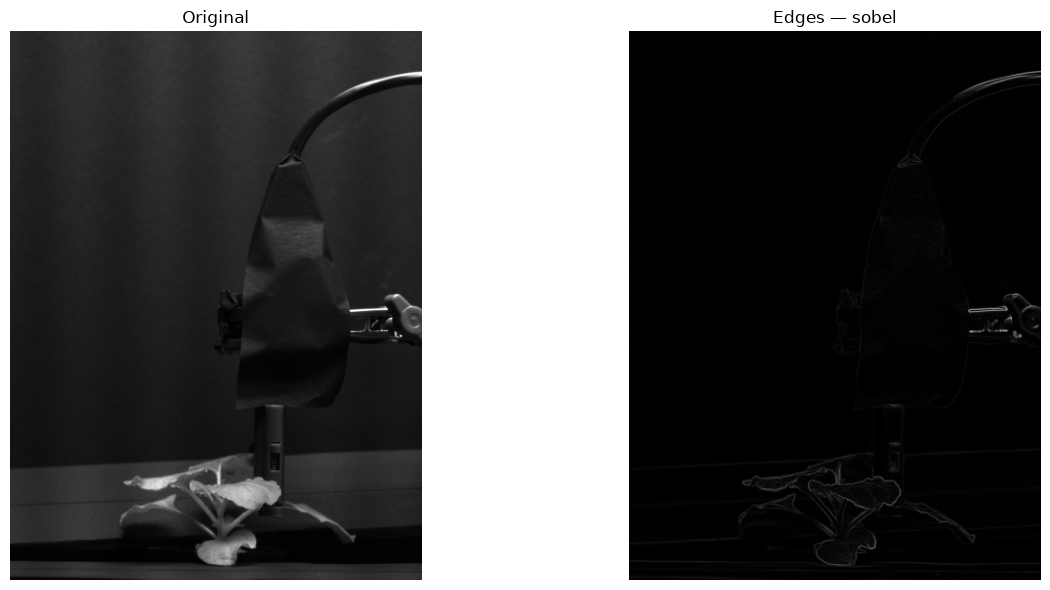

In [62]:
# --- Step 2b: edge detection + plot (collapse when done tuning) ---


def find_edges_u16(image: np.ndarray, method: str) -> np.ndarray:
    """Return a 16-bit edge-strength map for downstream thresholding."""
    method = method.lower()
    if image.dtype not in (np.uint8, np.uint16):
        raise TypeError(f"Expected uint8 or uint16 image; got {image.dtype}")

    if method in ("sobel", "scharr"):
        if method == "sobel":
            gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=GRADIENT_KSIZE)
            gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=GRADIENT_KSIZE)
        else:
            gx = cv2.Scharr(image, cv2.CV_32F, 1, 0)
            gy = cv2.Scharr(image, cv2.CV_32F, 0, 1)
        strength = cv2.magnitude(gx, gy)

    elif method == "laplacian":
        strength = np.abs(cv2.Laplacian(image, cv2.CV_32F, ksize=GRADIENT_KSIZE))

    elif method == "prewitt":
        kx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
        ky = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)
        gx = cv2.filter2D(image.astype(np.float32), cv2.CV_32F, kx)
        gy = cv2.filter2D(image.astype(np.float32), cv2.CV_32F, ky)
        strength = cv2.magnitude(gx, gy)

    elif method == "canny":
        gray_u8 = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        binary = cv2.Canny(gray_u8, CANNY_LOW, CANNY_HIGH)
        strength = binary.astype(np.float32)

    else:
        raise ValueError(
            f"Unknown EDGE_METHOD {method!r}; choose sobel, scharr, laplacian, canny, or prewitt"
        )

    return cv2.normalize(strength, None, 0, 65535, cv2.NORM_MINMAX).astype(np.uint16)


edges_u16 = find_edges_u16(gray, EDGE_METHOD)

print("method:", EDGE_METHOD)
print("edges dtype:", edges_u16.dtype, "min / max:", int(edges_u16.min()), int(edges_u16.max()))

edges_display = cv2.normalize(edges_u16, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(gray_display, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(edges_display, cmap="gray")
axes[1].set_title(f"Edges — {EDGE_METHOD}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Step 3 — Threshold edge image

Binary mask #1 from `edges_u16` (0 / 255 `uint8` → `mask_edges`).

**3a** — pick `THRESH_METHOD` and parameters.

**3b** — threshold, plot, and report the chosen level (collapse when done).

| `THRESH_METHOD` | Idea |
|---------------|------|
| `"otsu"` | Otsu on the edge histogram (full 16-bit for `edges_u16`) |
| `"triangle"` | OpenCV triangle (edges scaled to 8-bit first if needed) |
| `"percentile"` | ImageJ-style: threshold = percentile of edge strengths (`PERCENTILE`, 0–100) |

In [86]:
# --- Step 3a: threshold settings (edit here, then run 3b) ---

THRESH_METHOD = "percentile"  # otsu | triangle | percentile
PERCENTILE = 95.0           # only used when THRESH_METHOD == "percentile" (0–100)

method: percentile
threshold level: 2127.0
foreground pixels: 251837


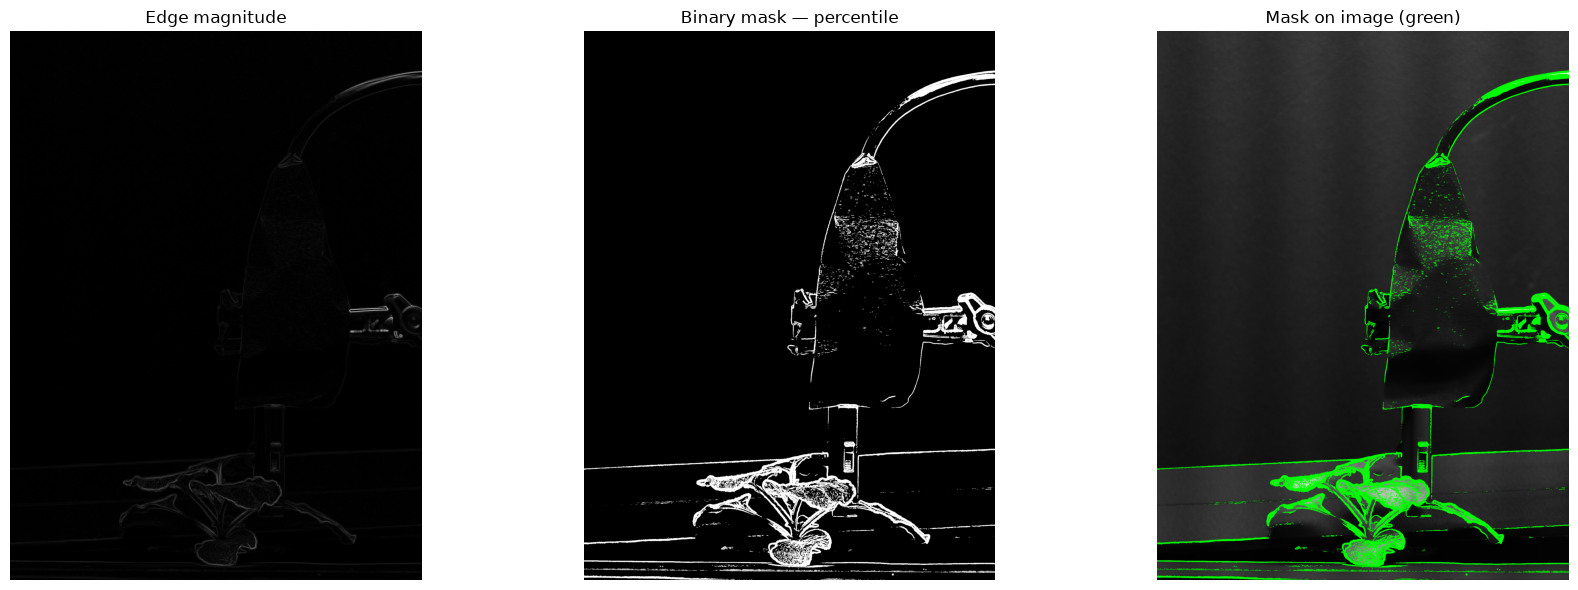

In [87]:
# --- Step 3b: threshold edges + plot (collapse when done tuning) ---


def _otsu_level_u16(edges: np.ndarray) -> int:
    hist = np.bincount(edges.ravel(), minlength=65536).astype(np.float64)
    total = hist.sum()
    if total <= 0:
        return 0
    p = hist / total
    idx = np.arange(len(hist), dtype=np.float64)
    w0 = np.cumsum(p)
    w1 = 1.0 - w0
    mu = np.cumsum(p * idx)
    mu_t = mu[-1]
    valid = (w0 > 1e-12) & (w1 > 1e-12)
    sb2 = np.zeros_like(idx)
    sb2[valid] = (mu_t * w0[valid] - mu[valid]) ** 2 / (w0[valid] * w1[valid])
    return int(np.argmax(sb2))


def threshold_edges(edges: np.ndarray, method: str) -> tuple[np.ndarray, float]:
    """Return (binary_mask_uint8, threshold_level)."""
    method = method.lower()
    if edges.dtype not in (np.uint8, np.uint16):
        raise TypeError(f"Expected uint8 or uint16 edges; got {edges.dtype}")

    if method == "otsu":
        if edges.dtype == np.uint8:
            level, mask = cv2.threshold(edges, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            return mask.astype(np.uint8), float(level)
        level = _otsu_level_u16(edges)
        mask = np.where(edges > level, 255, 0).astype(np.uint8)
        return mask, float(level)

    if method == "triangle":
        if edges.dtype == np.uint8:
            level, mask = cv2.threshold(edges, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)
            return mask.astype(np.uint8), float(level)
        emin, emax = int(edges.min()), int(edges.max())
        if emax <= emin:
            return np.zeros(edges.shape, dtype=np.uint8), float(emin)
        edges_u8 = np.clip(
            (edges.astype(np.float32) - emin) / (emax - emin) * 255.0, 0.0, 255.0
        ).astype(np.uint8)
        level, mask = cv2.threshold(edges_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)
        return mask.astype(np.uint8), float(level)

    if method == "percentile":
        level = float(np.percentile(edges, PERCENTILE))
        mask = np.where(edges > level, 255, 0).astype(np.uint8)
        return mask, level

    raise ValueError(
        f"Unknown THRESH_METHOD {method!r}; choose otsu, triangle, or percentile"
    )


mask_edges, thresh_level = threshold_edges(edges_u16, THRESH_METHOD)

print("method:", THRESH_METHOD)
print("threshold level:", thresh_level)
print("foreground pixels:", int((mask_edges > 0).sum()))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(edges_display, cmap="gray")
axes[0].set_title("Edge magnitude")
axes[0].axis("off")
axes[1].imshow(mask_edges, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Binary mask — {THRESH_METHOD}")
axes[1].axis("off")
overlay = cv2.cvtColor(gray_display, cv2.COLOR_GRAY2BGR)
overlay[mask_edges > 0] = (0, 255, 0)
axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title("Mask on image (green)")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## Step 4 — Gaussian blur on edge mask

Smear `mask_edges` into a soft blob (ImageJ-style **sigma in pixels**). Uses `cv2.GaussianBlur(mask, (0, 0), sigma)` so kernel size follows σ.

**4a** — set `MASK_BLUR_SIGMA` (try ~40; `0` disables blur).

**4b** — blur and plot hard edges vs soft mask (collapse when done).

In [25]:
# --- Step 4a: Gaussian blur settings (edit here, then run 4b) ---

MASK_BLUR_SIGMA = 50.0  # pixels; 0 = no blur

sigma: 50.0
soft mask min / max: 0 207


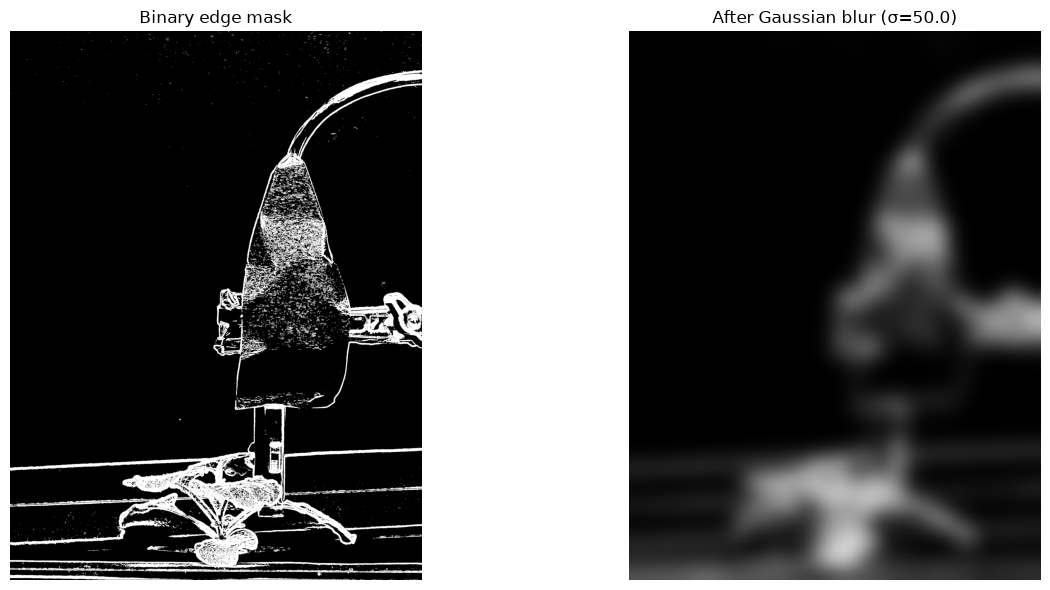

In [64]:
# --- Step 4b: blur edge mask + plot (collapse when done tuning) ---

def blur_binary_mask(mask: np.ndarray, sigma: float) -> np.ndarray:
    """Gaussian blur on a 0/255 uint8 mask; sigma in pixels (ImageJ-style)."""
    if mask.dtype != np.uint8:
        raise TypeError(f"mask must be uint8; got {mask.dtype}")
    if sigma <= 0:
        return mask.copy()
    return cv2.GaussianBlur(mask, (0, 0), float(sigma))

mask_soft = blur_binary_mask(mask_edges, MASK_BLUR_SIGMA)

print("sigma:", MASK_BLUR_SIGMA)
print("soft mask min / max:", int(mask_soft.min()), int(mask_soft.max()))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(mask_edges, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Binary edge mask")
axes[0].axis("off")
axes[1].imshow(mask_soft, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"After Gaussian blur (σ={MASK_BLUR_SIGMA})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Step 5 — Otsu threshold on soft mask

Binarize `mask_soft` into coarse blob(s) → `mask_blob`. OpenCV Otsu on 8-bit soft mask.

**5a** — optional `OTSU_MARGIN` (subtract from Otsu level to keep more interior; 0 = default).

**5b** — threshold and plot (collapse when done).

In [20]:
# --- Step 5a: post-blur Otsu settings (edit here, then run 5b) ---

OTSU_MARGIN = 0  # subtract from raw Otsu level (0–255); higher → more foreground kept

Otsu level (after margin): 55.0
foreground pixels: 875428


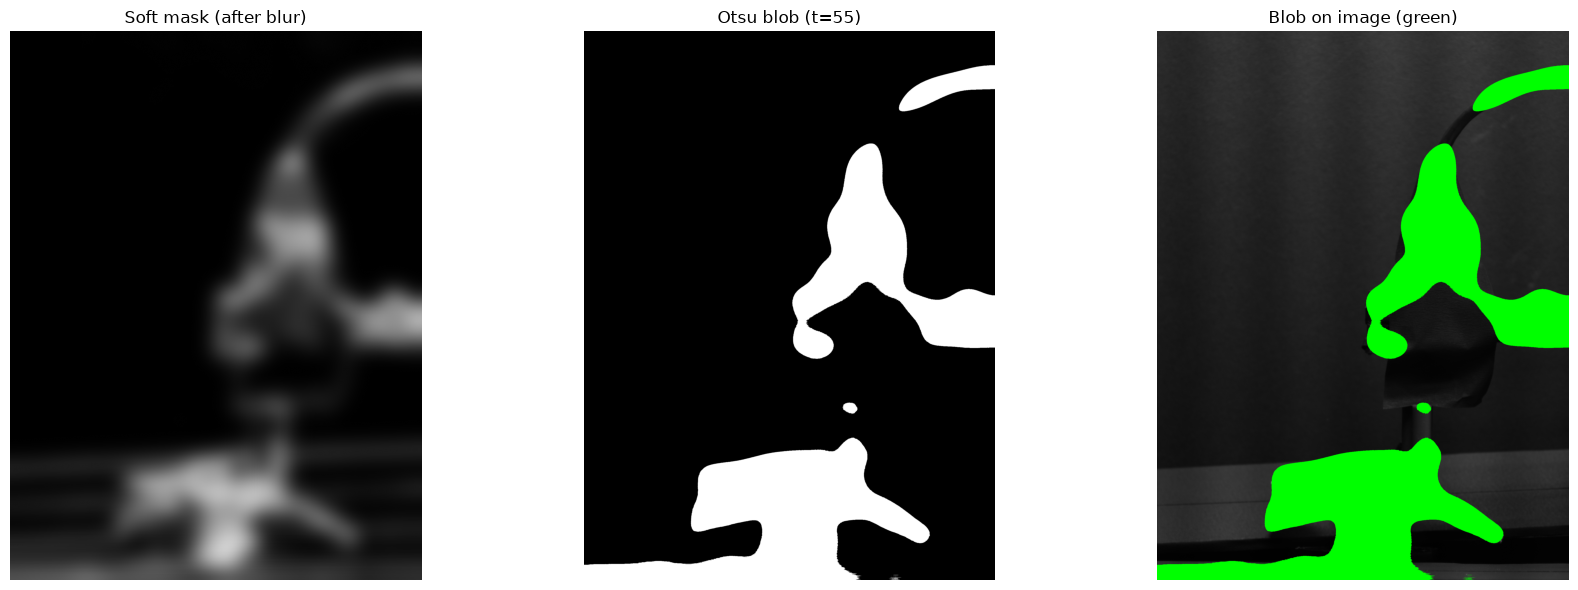

In [65]:
# --- Step 5b: Otsu on soft mask + plot (collapse when done tuning) ---


def otsu_binary_soft(soft: np.ndarray, otsu_margin: int = 0) -> tuple[np.ndarray, float]:
    """Binarize blurred uint8 mask with Otsu (+ optional margin)."""
    if soft.dtype != np.uint8:
        raise TypeError(f"soft mask must be uint8; got {soft.dtype}")
    level, _ = cv2.threshold(soft, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    t = int(np.clip(int(round(float(level))) - int(otsu_margin), 0, 255))
    mask = np.where(soft > t, 255, 0).astype(np.uint8)
    return mask, float(t)


mask_blob, blob_thresh = otsu_binary_soft(mask_soft, OTSU_MARGIN)

print("Otsu level (after margin):", blob_thresh)
print("foreground pixels:", int((mask_blob > 0).sum()))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(mask_soft, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Soft mask (after blur)")
axes[0].axis("off")
axes[1].imshow(mask_blob, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Otsu blob (t={blob_thresh:.0f})")
axes[1].axis("off")
overlay = cv2.cvtColor(gray_display, cv2.COLOR_GRAY2BGR)
overlay[mask_blob > 0] = (0, 255, 0)
axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title("Blob on image (green)")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## Step 6 — Isolate plant blob & refine mask

Pick one connected component from `mask_blob` → `mask_plant_roi`, then merge with the edge mask:

`mask_refined = mask_edges AND mask_plant_roi`

**6a** — selection mode and filters.

**6b** — run, print candidate stats, plot large CCs / plant ROI / final refined mask.

In [66]:
# --- Step 6a: connected-component selection (edit here, then run 6b) ---

CC_SELECT_MODE = "lowest_centroid"  # largest_area | lowest_centroid | bottom_band_score
MIN_COMPONENT_AREA = 500            # ignore tiny specks / lines
BOTTOM_BAND_FRAC = 0.45           # bottom fraction of image (for bottom_band_score)

mode: lowest_centroid
chosen label: 9
candidates:
  label= 9  area= 480294  cy=2295.0  bottom_px=480294
  label= 2  area= 345689  cy=1123.6  bottom_px= 40274
  label= 1  area=  46471  cy= 259.6  bottom_px=     0
  label= 6  area=   2680  cy=1778.6  bottom_px=  2680
plant ROI pixels: 480294
refined mask pixels: 224109


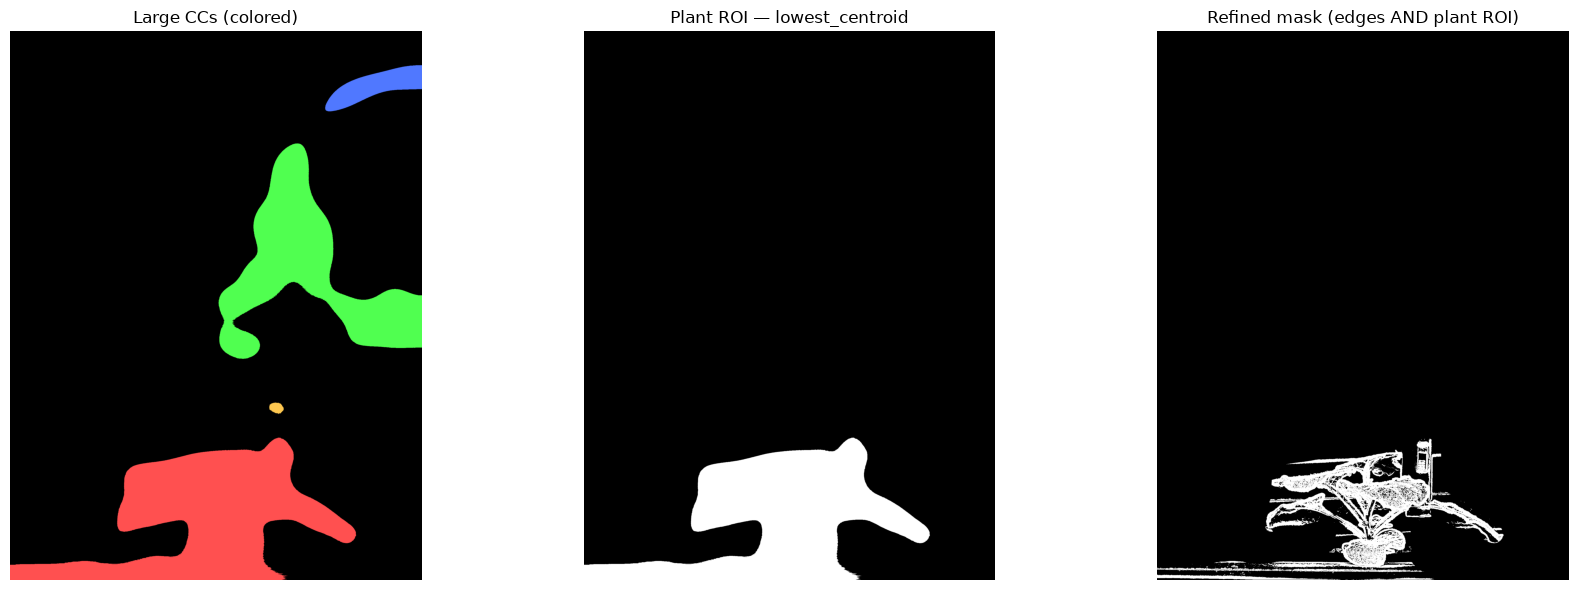

In [67]:
# --- Step 6b: select plant ROI + plot (collapse when done tuning) ---


def select_plant_component(
    mask: np.ndarray,
    mode: str,
    *,
    min_area: int,
    bottom_band_frac: float,
) -> tuple[np.ndarray, int, list[dict]]:
    """Return (plant_roi_mask, chosen_label, candidate_rows)."""
    mode = mode.lower()
    if mask.dtype != np.uint8:
        raise TypeError(f"mask must be uint8; got {mask.dtype}")

    fg = (mask > 127).astype(np.uint8)
    n, labels, stats, centroids = cv2.connectedComponentsWithStats(fg, connectivity=8)
    if n <= 1:
        return np.zeros_like(mask), 0, []

    h, w = mask.shape
    y_cut = int(round(h * (1.0 - float(bottom_band_frac))))

    candidates: list[dict] = []
    for label in range(1, n):
        area = int(stats[label, cv2.CC_STAT_AREA])
        if area < min_area:
            continue
        cx, cy = centroids[label]
        ys, xs = np.where(labels == label)
        bottom_pixels = int((ys >= y_cut).sum())
        candidates.append(
            {
                "label": label,
                "area": area,
                "centroid_y": float(cy),
                "bottom_pixels": bottom_pixels,
            }
        )

    if not candidates:
        return np.zeros_like(mask), 0, []

    if mode == "largest_area":
        chosen = max(candidates, key=lambda c: c["area"])
    elif mode == "lowest_centroid":
        chosen = max(candidates, key=lambda c: c["centroid_y"])
    elif mode == "bottom_band_score":
        chosen = max(candidates, key=lambda c: c["bottom_pixels"])
    else:
        raise ValueError(
            f"Unknown CC_SELECT_MODE {mode!r}; choose largest_area, lowest_centroid, or bottom_band_score"
        )

    out = np.zeros_like(mask)
    out[labels == chosen["label"]] = 255
    return out, int(chosen["label"]), candidates


mask_plant_roi, plant_label, cc_candidates = select_plant_component(
    mask_blob,
    CC_SELECT_MODE,
    min_area=MIN_COMPONENT_AREA,
    bottom_band_frac=BOTTOM_BAND_FRAC,
)

print("mode:", CC_SELECT_MODE)
print("chosen label:", plant_label)
print("candidates:")
for row in sorted(cc_candidates, key=lambda r: -r["area"]):
    print(
        f"  label={row['label']:2d}  area={row['area']:7d}  "
        f"cy={row['centroid_y']:6.1f}  bottom_px={row['bottom_pixels']:6d}"
    )
print("plant ROI pixels:", int((mask_plant_roi > 0).sum()))

mask_refined = cv2.bitwise_and(mask_edges, mask_plant_roi)
print("refined mask pixels:", int((mask_refined > 0).sum()))

_fg = (mask_blob > 127).astype(np.uint8)
_n, _labels, _, _ = cv2.connectedComponentsWithStats(_fg, connectivity=8)
cc_vis = np.zeros((*mask_blob.shape, 3), dtype=np.uint8)
palette = [
    (255, 80, 80),
    (80, 255, 80),
    (80, 120, 255),
    (255, 200, 80),
    (200, 80, 255),
    (80, 255, 255),
]
for i, row in enumerate(sorted(cc_candidates, key=lambda r: -r["area"])):
    cc_vis[_labels == row["label"]] = palette[i % len(palette)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cc_vis)
axes[0].set_title("Large CCs (colored)")
axes[0].axis("off")
axes[1].imshow(mask_plant_roi, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Plant ROI — {CC_SELECT_MODE}")
axes[1].axis("off")
axes[2].imshow(mask_refined, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Refined mask (edges AND plant ROI)")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## Step 7 — Remove salt-and-pepper outliers

Clean `mask_refined` → `mask_clean`.

**7a** — denoise method and parameters.

**7b** — run; plot before / after / difference (red = removed, green = added).

| `OUTLIER_METHOD` | Effect |
|------------------|--------|
| `"morph_open_close"` | Opening removes white specks (salt); closing fills black holes (pepper) |
| `"median"` | Median filter then re-binarize |
| `"imagej_outliers"` | ImageJ *Remove Outliers*: replace pixels far from local median |
| `"min_area"` | Drop small connected components below `MIN_SPECK_AREA` |

In [68]:
# --- Step 7a: outlier / salt-and-pepper settings (edit here, then run 7b) ---

OUTLIER_METHOD = "imagej_outliers"  # morph_open_close | median | imagej_outliers | min_area

# morph_open_close / median
MORPH_KERNEL_SIZE = 3   # odd integer ≥ 3
MEDIAN_KSIZE = 3        # odd integer ≥ 3

# imagej_outliers
OUTLIER_RADIUS = 2.0    # neighborhood radius (pixels); 0 = skip
OUTLIER_THRESHOLD = 100  # 0–255; max deviation from local median
OUTLIER_WHICH = "both"  # bright | dark | both  (salt=bright, pepper=dark)

# min_area
MIN_SPECK_AREA = 30     # drop foreground blobs smaller than this

method: imagej_outliers
before pixels: 224109
after pixels: 233241
removed pixels: 5809
added pixels: 14941
net change: 9132


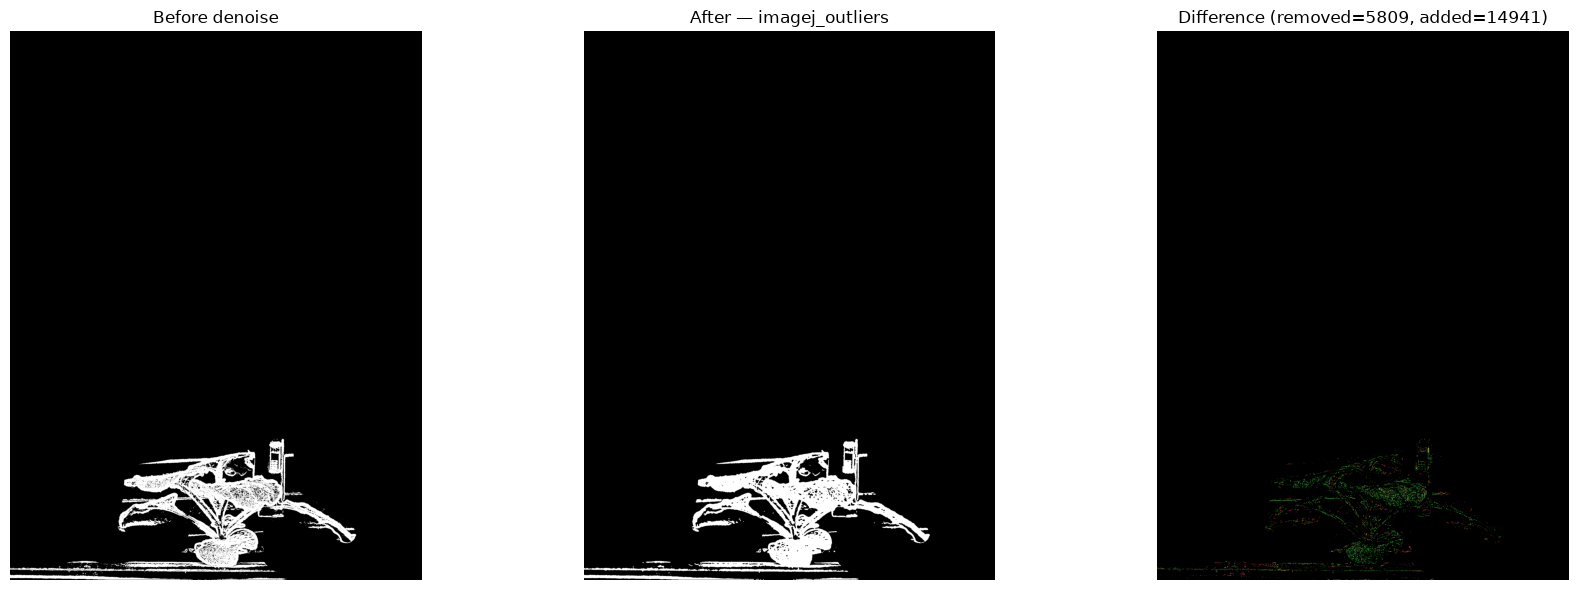

In [69]:
# --- Step 7b: denoise mask + plot (collapse when done tuning) ---


def _odd_kernel(k: int, minimum: int = 3) -> int:
    k = max(minimum, int(k))
    return k if k % 2 == 1 else k + 1


def remove_mask_outliers(mask: np.ndarray, method: str) -> np.ndarray:
    """Return cleaned uint8 mask (0 / 255)."""
    method = method.lower()
    if mask.dtype != np.uint8:
        raise TypeError(f"mask must be uint8; got {mask.dtype}")

    if method == "morph_open_close":
        k = _odd_kernel(MORPH_KERNEL_SIZE)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        return cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    if method == "median":
        k = _odd_kernel(MEDIAN_KSIZE)
        blurred = cv2.medianBlur(mask, k)
        return np.where(blurred > 127, 255, 0).astype(np.uint8)

    if method == "imagej_outliers":
        if OUTLIER_RADIUS <= 0:
            return mask.copy()
        k = _odd_kernel(int(2 * np.ceil(float(OUTLIER_RADIUS)) + 1))
        k = min(k, 255)
        med = cv2.medianBlur(mask, k)
        out = mask.copy()
        i16 = mask.astype(np.int16)
        m16 = med.astype(np.int16)
        th = float(OUTLIER_THRESHOLD)
        which = OUTLIER_WHICH.lower()
        if which in ("bright", "both"):
            out[(i16 - m16) > th] = med[(i16 - m16) > th]
        if which in ("dark", "both"):
            out[(m16 - i16) > th] = med[(m16 - i16) > th]
        return out

    if method == "min_area":
        fg = (mask > 127).astype(np.uint8)
        n, labels, stats, _ = cv2.connectedComponentsWithStats(fg, connectivity=8)
        out = np.zeros_like(mask)
        for label in range(1, n):
            if int(stats[label, cv2.CC_STAT_AREA]) >= MIN_SPECK_AREA:
                out[labels == label] = 255
        return out

    raise ValueError(
        f"Unknown OUTLIER_METHOD {method!r}; choose morph_open_close, median, "
        "imagej_outliers, or min_area"
    )


mask_clean = remove_mask_outliers(mask_refined, OUTLIER_METHOD)

removed = (mask_refined > 0) & (mask_clean == 0)
added = (mask_clean > 0) & (mask_refined == 0)
n_removed = int(removed.sum())
n_added = int(added.sum())

print("method:", OUTLIER_METHOD)
print("before pixels:", int((mask_refined > 0).sum()))
print("after pixels:", int((mask_clean > 0).sum()))
print("removed pixels:", n_removed)
print("added pixels:", n_added)
print("net change:", int((mask_clean > 0).sum()) - int((mask_refined > 0).sum()))

diff_vis = np.zeros((*mask_refined.shape, 3), dtype=np.uint8)
diff_vis[removed] = (255, 80, 80)   # red = foreground removed (salt)
diff_vis[added] = (80, 255, 80)     # green = foreground added (pepper filled)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(mask_refined, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Before denoise")
axes[0].axis("off")
axes[1].imshow(mask_clean, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"After — {OUTLIER_METHOD}")
axes[1].axis("off")
axes[2].imshow(diff_vis)
axes[2].set_title(f"Difference (removed={n_removed}, added={n_added})")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## Step 8 — Fill small holes (not petiole gaps)

Input: `mask_clean` → output: `mask_filled`.

**Do not** flood-fill all interior holes — that would close real background between petioles. Instead fill only **enclosed background blobs smaller than `MAX_HOLE_AREA`**.

**8a** — fill method and size limit.

**8b** — run; before / after plot.

| `FILL_METHOD` | Behavior |
|---------------|----------|
| `"area_limited"` | Fill interior holes with area ≤ `MAX_HOLE_AREA` (recommended) |
| `"morph_close"` | Morphological closing — fills gaps narrower than kernel |
| `"fill_all"` | ImageJ-style flood-fill of every interior hole (aggressive; may close petiole gaps) |

In [82]:
# --- Step 8a: hole-fill settings (edit here, then run 8b) ---

FILL_METHOD = "morph_close"  # area_limited | morph_close | fill_all
MAX_HOLE_AREA = 500           # area_limited: max enclosed hole size (pixels); raise to fill more
CLOSE_KERNEL_SIZE = 15         # morph_close: odd kernel; fills gaps narrower than this

method: morph_close
before pixels: 233241
after pixels: 267648
newly filled pixels: 34407


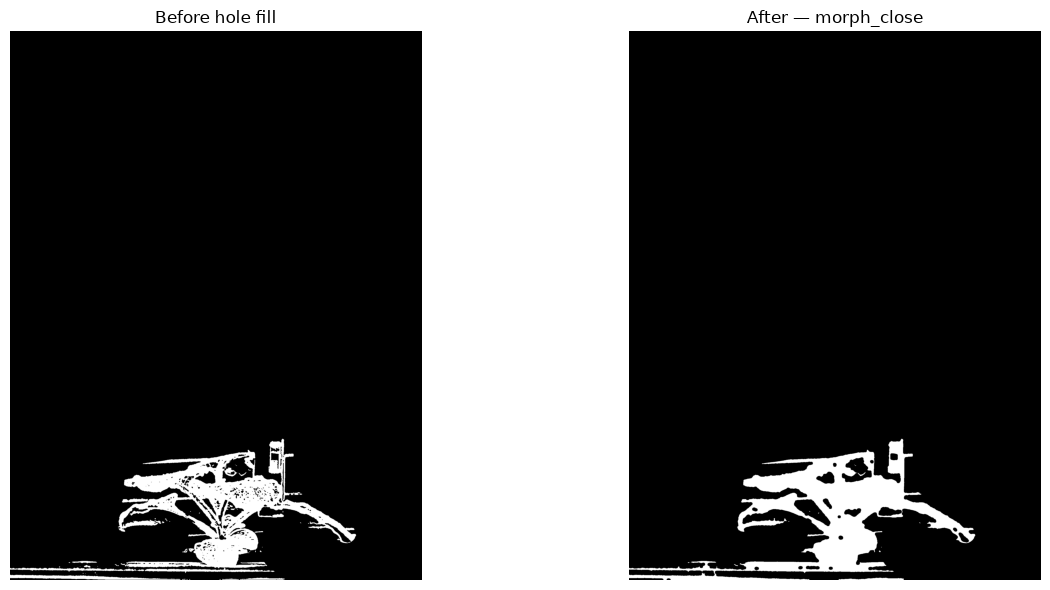

In [83]:
# --- Step 8b: fill holes + plot (collapse when done tuning) ---


def _odd_kernel(k: int, minimum: int = 3) -> int:
    k = max(minimum, int(k))
    return k if k % 2 == 1 else k + 1


def fill_holes_in_mask(mask: np.ndarray, method: str) -> np.ndarray:
    """Fill interior holes in a uint8 plant mask without closing large petiole gaps."""
    method = method.lower()
    if mask.dtype != np.uint8:
        raise TypeError(f"mask must be uint8; got {mask.dtype}")

    fg = (mask > 127).astype(np.uint8)

    if method == "area_limited":
        bg = (1 - fg).astype(np.uint8)
        h, w = bg.shape
        n, labels, stats, _ = cv2.connectedComponentsWithStats(bg, connectivity=8)
        out = (fg * 255).astype(np.uint8)
        filled_holes = 0
        for label in range(1, n):
            x = int(stats[label, cv2.CC_STAT_LEFT])
            y = int(stats[label, cv2.CC_STAT_TOP])
            bw = int(stats[label, cv2.CC_STAT_WIDTH])
            bh = int(stats[label, cv2.CC_STAT_HEIGHT])
            area = int(stats[label, cv2.CC_STAT_AREA])
            touches_border = x <= 0 or y <= 0 or (x + bw) >= w or (y + bh) >= h
            if touches_border:
                continue
            if area <= MAX_HOLE_AREA:
                out[labels == label] = 255
                filled_holes += 1
        print("interior holes filled:", filled_holes)
        return out

    if method == "morph_close":
        k = _odd_kernel(CLOSE_KERNEL_SIZE)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        return cv2.morphologyEx(fg * 255, cv2.MORPH_CLOSE, kernel)

    if method == "fill_all":
        bin_in = fg * 255
        flood = bin_in.copy()
        fill_mask = np.zeros((bin_in.shape[0] + 2, bin_in.shape[1] + 2), dtype=np.uint8)
        cv2.floodFill(flood, fill_mask, (0, 0), 255)
        hole_inv = cv2.bitwise_not(flood)
        return cv2.bitwise_or(bin_in, hole_inv)

    raise ValueError(
        f"Unknown FILL_METHOD {method!r}; choose area_limited, morph_close, or fill_all"
    )


mask_filled = fill_holes_in_mask(mask_clean, FILL_METHOD)

n_filled = int(((mask_clean == 0) & (mask_filled > 0)).sum())

print("method:", FILL_METHOD)
print("before pixels:", int((mask_clean > 0).sum()))
print("after pixels:", int((mask_filled > 0).sum()))
print("newly filled pixels:", n_filled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(mask_clean, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Before hole fill")
axes[0].axis("off")
axes[1].imshow(mask_filled, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"After — {FILL_METHOD}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Step 9 — Skeletonize `mask_filled` (PlantCV)

Input: `mask_filled` (uint8 plant mask) → outputs: `skeleton`, `segmented_skeleton`, `segment_objects`.

This mirrors the PlantCV morphology tutorial: convert the OpenCV mask to a PlantCV mask, then skeletonize it.

**9a** — options for thinning method and a quick overlay check.

**9b** — run `pcv.morphology.skeletonize`; plot skeleton + overlay on `mask_filled`.


In [84]:
# --- Step 9a: skeletonization options (edit here, then run 9b) ---

# PlantCV currently uses a single thinning algorithm under the hood; this switch is here
# in case we add alternatives later (e.g. Zhang–Suen vs. Guo–Hall) or want to tweak behavior.
SKELETON_METHOD = "plantcv_default"  # plantcv_default (only option for now)

# Quick sanity flag: if False, 9b will still compute the skeleton but skip plotting overlays
SHOW_SKELETON_PLOTS = True

# Plot resolution: higher DPI + taller figure = sharper notebook output
SKELETON_PLOT_DPI = 150
SKELETON_PLOT_HEIGHT_IN = 12  # figure height in inches; width scales with image aspect

skeleton dtype: uint8
skeleton nonzero pixels: 9208


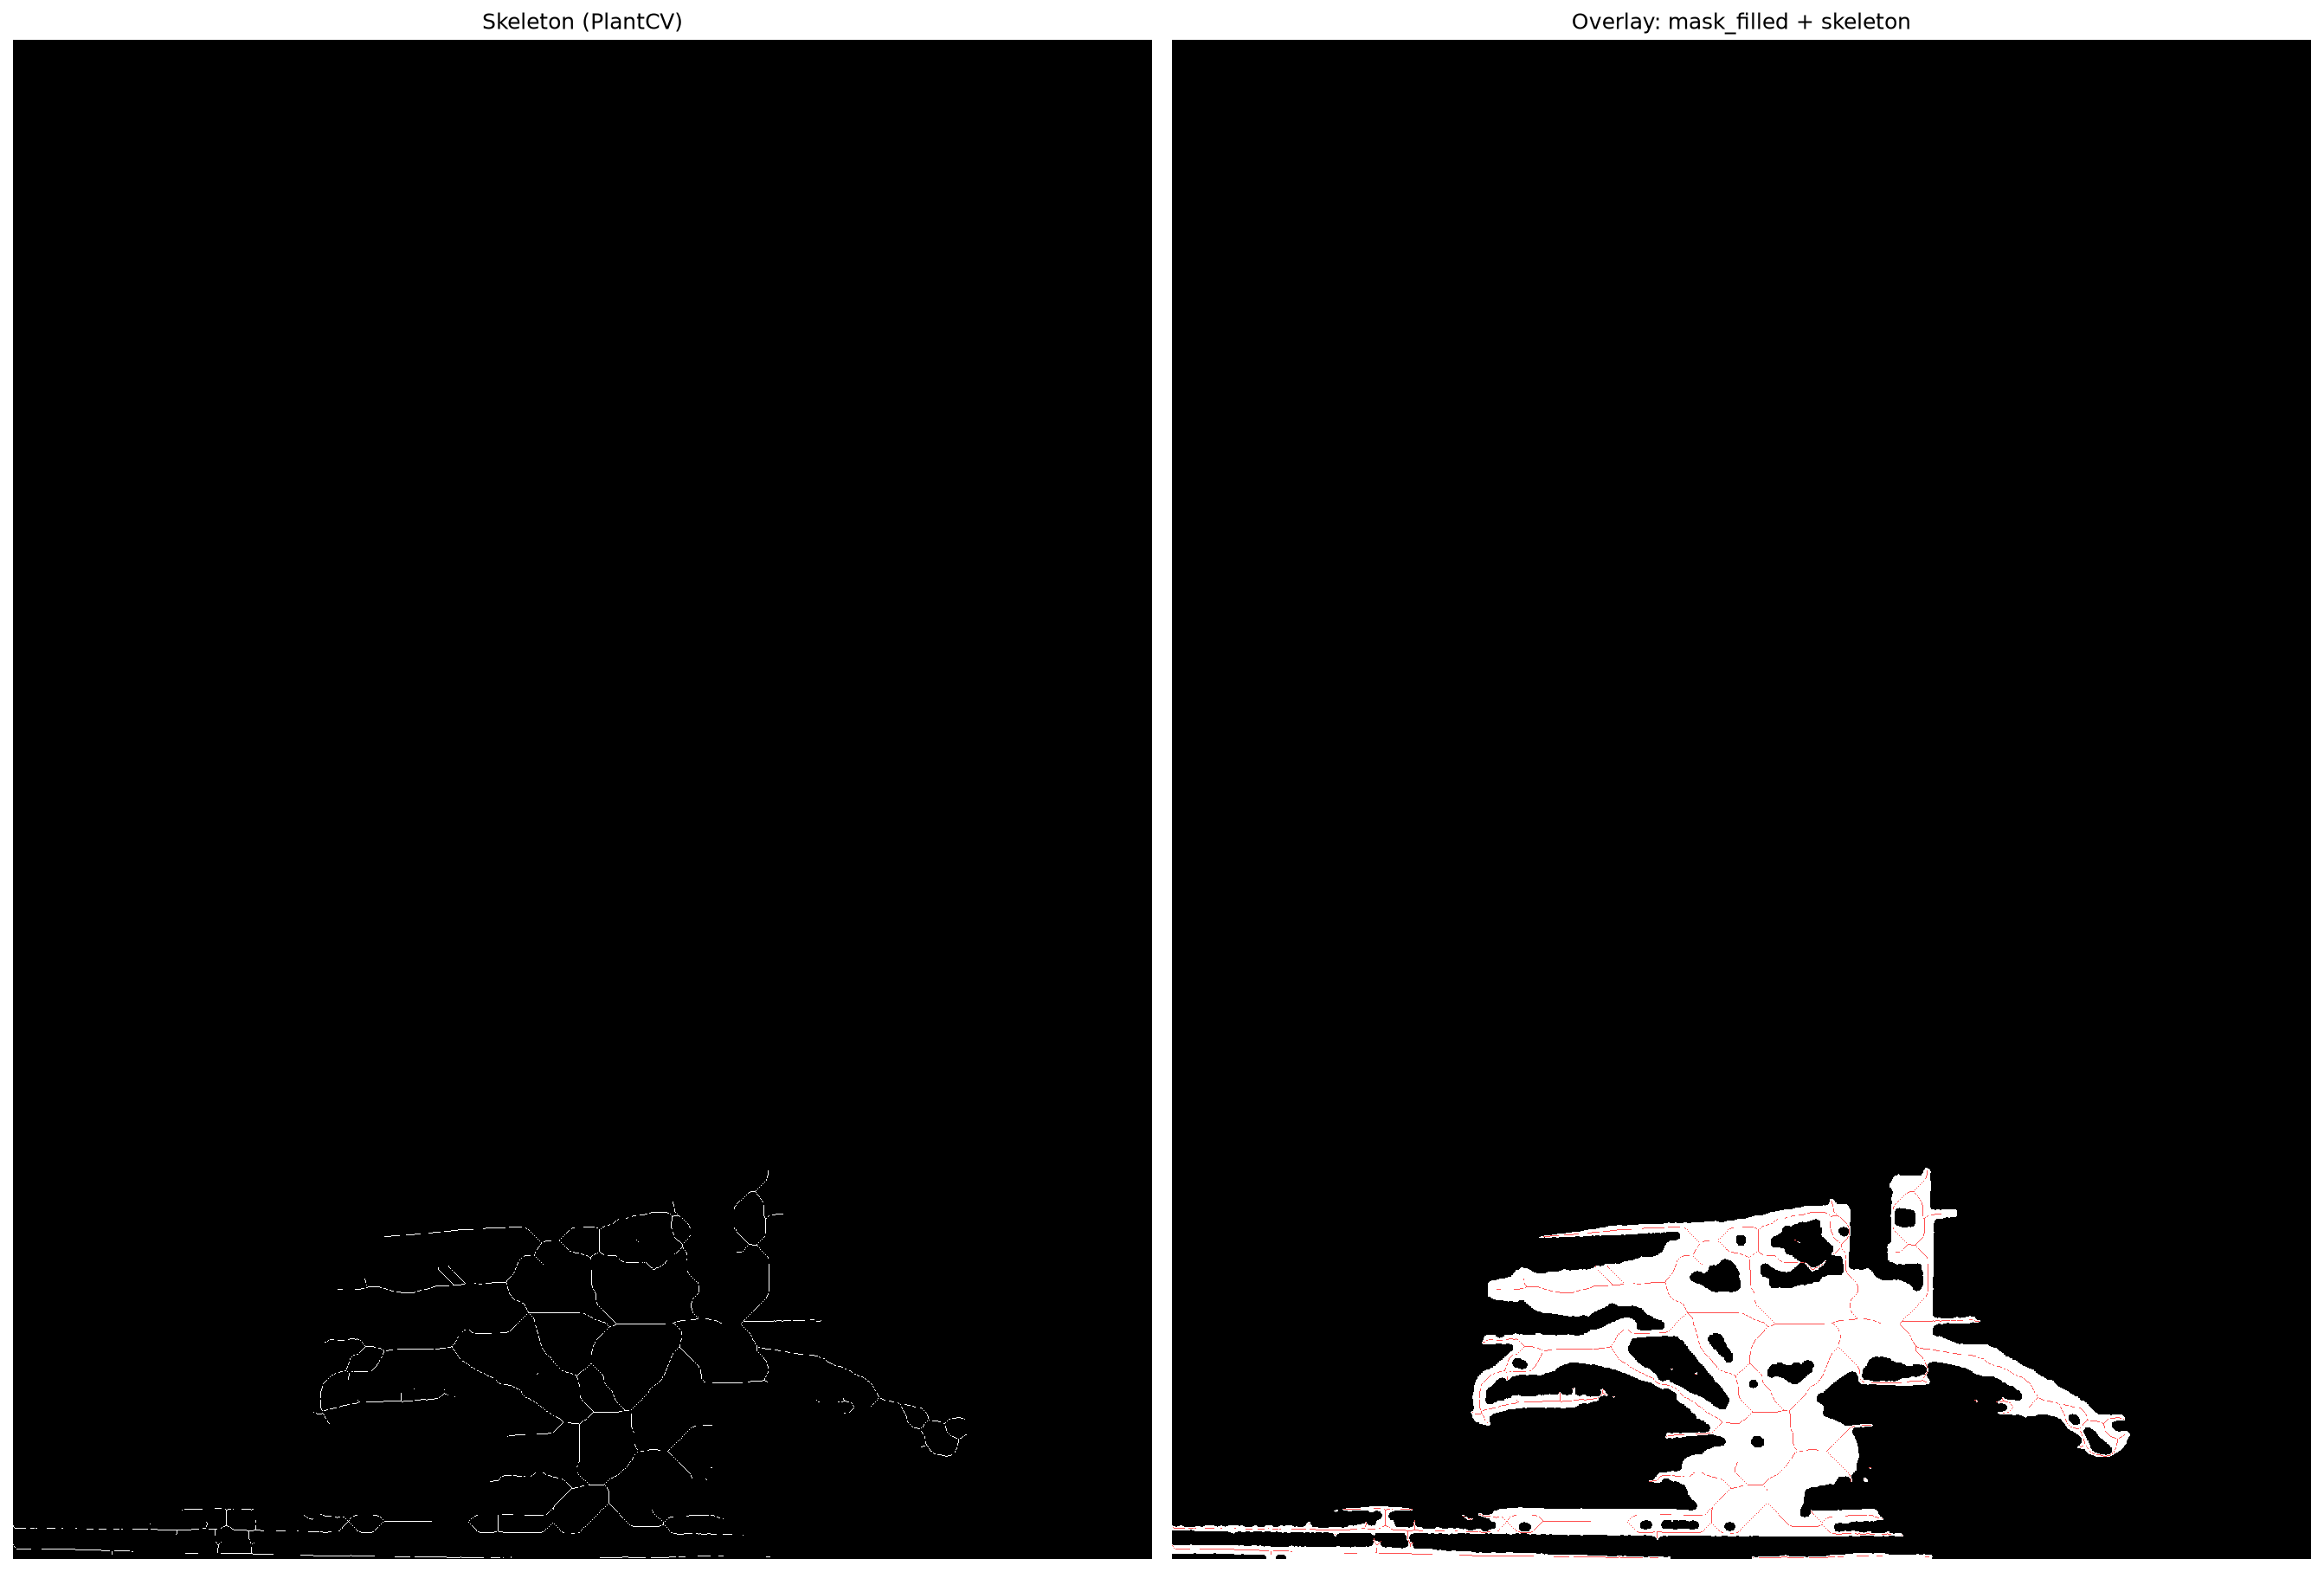

In [85]:
# --- Step 9b: skeletonize `mask_filled` and visualize ---

if "mask_filled" not in globals():
    raise RuntimeError("mask_filled is not defined — run Steps 1–8 first.")

# PlantCV expects a binary mask; our `mask_filled` is already uint8 {0,255}.
# Convert to PlantCV-format mask and skeletonize.

# pcv expects a 2D numpy array; we already have that from OpenCV.
mask_pc = mask_filled.copy()

if mask_pc.dtype != np.uint8:
    raise TypeError(f"mask_filled must be uint8; got {mask_pc.dtype}")

# PlantCV uses 1/0 internally; both {0,255} and {0,1} work, but we keep 0/255 for plotting.

pcv.params.debug = None  # or "plot" if you want PlantCV's own debug windows

skeleton = pcv.morphology.skeletonize(mask_pc)

print("skeleton dtype:", skeleton.dtype)
print("skeleton nonzero pixels:", int((skeleton > 0).sum()))

if SHOW_SKELETON_PLOTS:
    overlay = cv2.cvtColor(mask_pc, cv2.COLOR_GRAY2RGB)
    overlay[skeleton > 0] = (255, 80, 80)  # red skeleton on top of mask

    h, w = skeleton.shape
    panel_w_in = SKELETON_PLOT_HEIGHT_IN * (w / h)
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(2 * panel_w_in, SKELETON_PLOT_HEIGHT_IN),
        dpi=SKELETON_PLOT_DPI,
    )

    axes[0].imshow(skeleton, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    axes[0].set_title("Skeleton (PlantCV)")
    axes[0].axis("off")

    axes[1].imshow(overlay, interpolation="nearest")
    axes[1].set_title("Overlay: mask_filled + skeleton")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()